# Maine Election Analysis

## Import Libraries

In [6]:
from matplotlib.patches import Patch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
csv_path = "senate.csv"
data = pd.read_csv(csv_path)

## Historical data results from the 2024 Maine Senate Race: Democrat, Republican, and Third Party

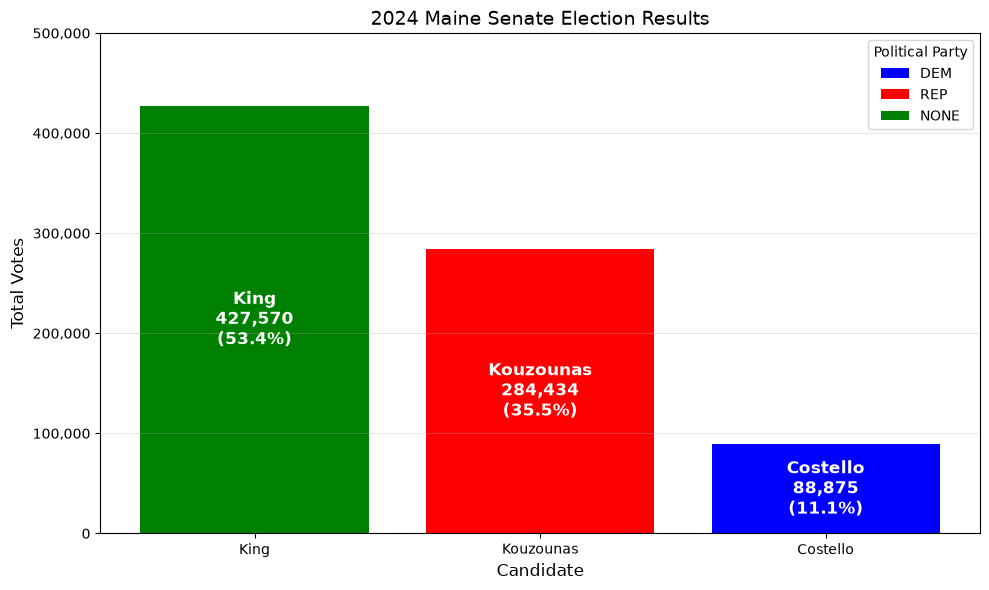

In [7]:
# Use the following data for 2024 election results
dem_results = 88875
rep_results = 284434
third_party_results = 427570
dem_percentage = (dem_results / (dem_results + rep_results + third_party_results)) * 100
rep_percentage = (rep_results / (dem_results + rep_results + third_party_results)) * 100
third_party_percentage = (third_party_results / (dem_results + rep_results + third_party_results)) * 100
data_2024 = pd.DataFrame([{'Answer': 'Costello', 'Political Party': 'DEM', 'Results': dem_results, 'Percentage': dem_percentage},
                          {'Answer': 'Kouzounas', 'Political Party': 'REP', 'Results': rep_results, 'Percentage': rep_percentage},
                          {'Answer': 'King', 'Political Party': 'NONE', 'Results': third_party_results, 'Percentage': third_party_percentage}])

# Sort by sample size (largest first)
data_2024 = data_2024.sort_values('Results', ascending=False)

# Clean index
data_2024.index = range(1, len(data_2024) + 1)
data_2024 = data_2024.head(3)

# Define colors for each party
party_colors = {'DEM': 'blue', 'REP': 'red', 'NONE': 'green'}

# Define colors for each party in the graph's legend
legend_elements = [
    Patch(facecolor='blue', label='DEM'),
    Patch(facecolor='red', label='REP'),
    Patch(facecolor='green', label='NONE')
]

# Create bar chart
plt.figure(figsize=(10, 6))

# Create bars with party colors
for candidate in data_2024['Answer']:
    # Get the party for this candidate
    party = data_2024[data_2024['Answer'] == candidate]['Political Party'].iloc[0]
    color = party_colors.get(party, 'gray')
    
    # Get the results (votes)
    results = data_2024[data_2024['Answer'] == candidate]['Results'].iloc[0]
    
    # Create the bar
    plt.bar(candidate, results, color=color)

# Add value labels INSIDE the bars (candidate name, votes, percentage)
for i, (candidate, results, percentage) in enumerate(zip(data_2024['Answer'], 
                                                          data_2024['Results'], 
                                                          data_2024['Percentage'])):
    # Format votes with commas
    votes_formatted = f"{results:,}"
    
    # Create the label text with candidate name, votes, and percentage
    label_text = f"{candidate}\n{votes_formatted}\n({percentage:.1f}%)"
    
    # Place text inside the bar (centered, with some offset from bottom)
    plt.text(i, results / 2,  # Position at half the bar height
             label_text,
             ha='center', 
             va='center', 
             fontsize=12,
             fontweight='bold',
             color='white')  # White text for contrast

plt.xlabel('Candidate', fontsize=12)
plt.ylabel('Total Votes', fontsize=12)
plt.title('2024 Maine Senate Election Results', fontsize=14)

# Format y-axis to show numbers with commas
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.grid(axis='y', alpha=0.3)

# Set y-axis limit to ensure bars are fully visible
plt.ylim(0, 500000)

# Add legend
plt.legend(handles=legend_elements, title='Political Party', loc='upper right')

plt.tight_layout()
plt.show()

## Data Results of Current Week's Polls, by Candidate

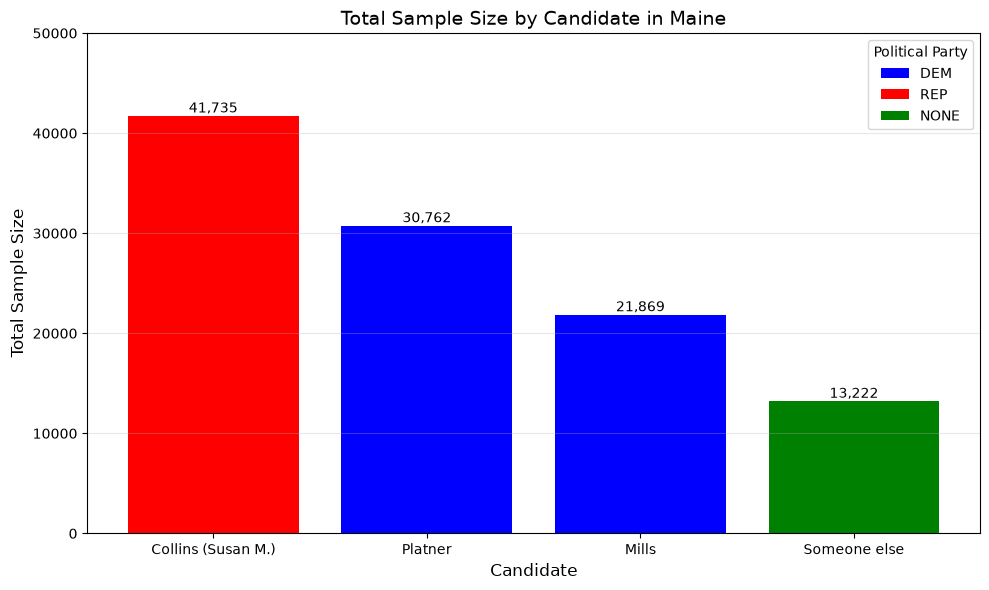

In [8]:
# Construct dataset by polling data sample size

# Rename columns
data = data.rename(columns={ 
    'state':'State', 
    'sample_size':'Sample Size', 
    'party':'Political Party', 
    'answer':'Answer'
})

# Filter: Maine AND (DEM or REP or NONE)
data = data[(data['State'] == 'ME') & (data['Political Party'].isin(['DEM', 'REP', 'NONE']))]

# Remove unwanted answers, data that is not useful for analysis
unwanted = ["Don't know", "Refused", "No opinion"]
data = data[~data['Answer'].isin(unwanted)]

# Remove duplicates
data = data.drop_duplicates()

# Group by Answer and Political Party, summing Sample Size
df_aggregated = data.groupby(['Answer', 'Political Party'])['Sample Size'].sum().reset_index()
df_aggregated = df_aggregated.sort_values('Sample Size', ascending=False)

# Sort by sample size (largest first)
df_aggregated = df_aggregated.sort_values('Sample Size', ascending=False)

# Clean index
df_aggregated.index = range(1, len(df_aggregated) + 1)
df_aggregated = df_aggregated.head(4)

# Define colors for each party
party_colors = {'DEM': 'blue', 'REP': 'red', 'NONE': 'green'}

# Define colors for each party in the graph's legend
if 'NONE' in df_aggregated['Political Party'].values:
    legend_elements = [
        Patch(facecolor='blue', label='DEM'),
        Patch(facecolor='red', label='REP'),
        Patch(facecolor='green', label='NONE') 
    ]
else:
    legend_elements = [
        Patch(facecolor='blue', label='DEM'),
        Patch(facecolor='red', label='REP'),
    ]

# Create bart chart
plt.figure(figsize=(10, 6))

# Create bars with party colors
for candidate in df_aggregated['Answer']:
    # Assign color and answer based on the candidate's political party
    party = df_aggregated[df_aggregated['Answer'] == candidate]['Political Party'].iloc[0]
    color = party_colors.get(party, 'gray')
    
    # Get the sample size
    sample_size = df_aggregated[df_aggregated['Answer'] == candidate]['Sample Size'].iloc[0]
    
    # Finalize the bar chart with the candidate's name, sample size, and color
    plt.bar(candidate, sample_size, color=color, label=party if candidate == df_aggregated['Answer'].iloc[0] else "")

# Add value labels
for i, (candidate, sample_size) in enumerate(zip(df_aggregated['Answer'], df_aggregated['Sample Size'])):
    plt.text(i, sample_size, f'{int(sample_size):,}', ha='center', va='bottom', fontsize=10)
    
# Set y-axis limit to ensure bars are fully visible
plt.ylim(0, 50000)

plt.xlabel('Candidate', fontsize=12)
plt.ylabel('Total Sample Size', fontsize=12)
plt.title('Total Sample Size by Candidate in Maine', fontsize=14)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add legend
plt.legend(handles=legend_elements, title='Political Party', loc='upper right')

plt.tight_layout()
plt.show()

## Data Results of Week's Polls, by Political Party

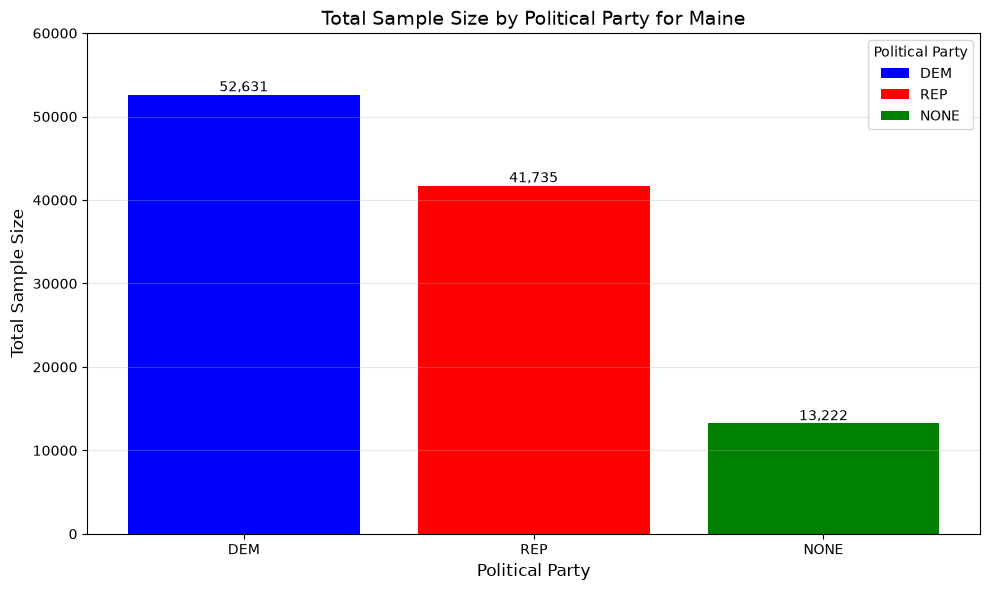

In [9]:
# Combine results if they are in the same Party
party_totals = df_aggregated.groupby('Political Party')['Sample Size'].sum().reset_index()

# Sort by sample size (largest first)
party_totals = party_totals.sort_values('Sample Size', ascending=False)

# Variable to hold the total sample size for the Democratic party
dem_total = party_totals.loc[party_totals['Political Party'] == 'DEM', 'Sample Size'].iloc[0]

# Variable to hold the total sample size for the Republican party
rep_total = party_totals.loc[party_totals['Political Party'] == 'REP', 'Sample Size'].iloc[0]

# Variable to hold the total sample size for third party candidates
if 'NONE' in party_totals['Political Party'].values:
    third_party_total = party_totals.loc[party_totals['Political Party'] == 'NONE', 'Sample Size'].iloc[0]

# Clean index
party_totals.index = range(1, len(party_totals) + 1)
if 'NONE' in party_totals['Political Party'].values:
    party_totals = party_totals.head(3)
else:
    party_totals = party_totals.head(2)

# Define colors for each party
party_colors = {'DEM': 'blue', 'REP': 'red', 'NONE': 'green'}

# Define colors for each party in the graph's legend
if 'NONE' in party_totals['Political Party'].values:
    legend_elements = [
        Patch(facecolor='blue', label='DEM'),
        Patch(facecolor='red', label='REP'),
        Patch(facecolor='green', label='NONE') 
    ]
else:
    legend_elements = [
        Patch(facecolor='blue', label='DEM'),
        Patch(facecolor='red', label='REP'),
    ]

# Create bart chart
plt.figure(figsize=(10, 6))

# Create bars with party colors
for party in party_totals['Political Party']:
    # Assign color
    color = party_colors.get(party, 'gray')
    
    # Get the sample size
    sample_size = party_totals[party_totals['Political Party'] == party]['Sample Size'].iloc[0]
    
    # Finalize the bar chart with the party's name, sample size, and color
    plt.bar(party, sample_size, color=color)

# Add value labels
for i, (party, sample_size) in enumerate(zip(party_totals['Political Party'], party_totals['Sample Size'])):
    plt.text(i, sample_size, f'{int(sample_size):,}', ha='center', va='bottom', fontsize=10)
    
# Set y-axis limit to ensure bars are fully visible
plt.ylim(0, 60000)

plt.xlabel('Political Party', fontsize=12)
plt.ylabel('Total Sample Size', fontsize=12)
plt.title('Total Sample Size by Political Party for Maine', fontsize=14)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add legend
plt.legend(handles=legend_elements, title='Political Party', loc='upper right')

plt.tight_layout()
plt.show()

## Consolidated data from historical results and projected results

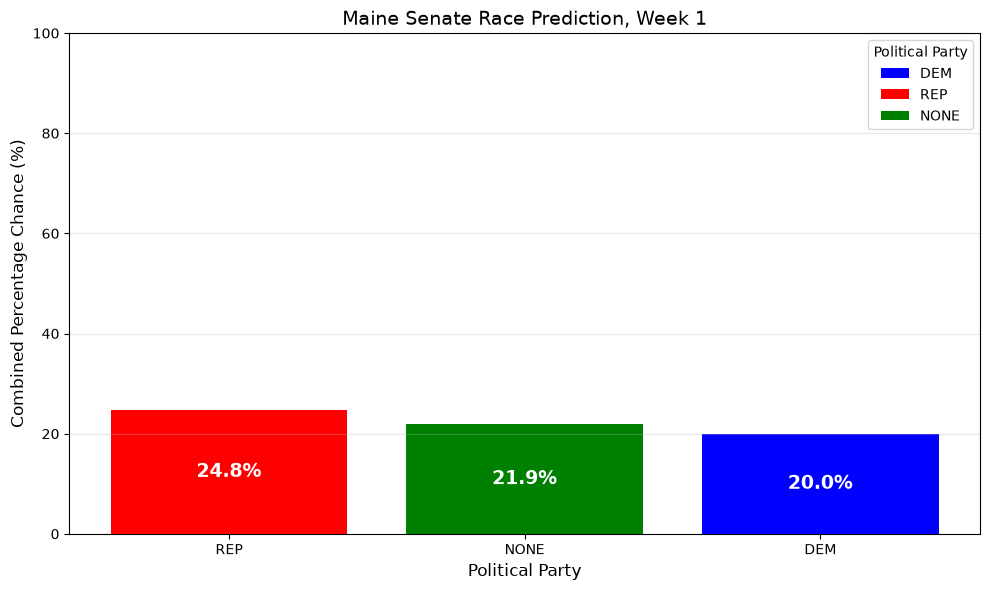

In [10]:
# Update Week **MANUALLY**
week = 1

# Combine the total sample sizes for both parties to get the consolidated data
consolidated_data = dem_total + rep_total + third_party_total

# Calculate the percentage of the total sample size for each party
consolidated_sample_size_dem_decimal = (dem_total / consolidated_data) * 100
consolidated_sample_size_rep_decimal = (rep_total / consolidated_data) * 100
consolidated_sample_size_third_party_decimal = (third_party_total / consolidated_data) * 100

# Calculate the percentage from the 2024 election results for each party and compare 
# it to the consolidated sample size percentages
if 'NONE' in party_totals['Political Party'].values:
    dem_percentage_chance = (consolidated_sample_size_dem_decimal + dem_percentage) / 3
    rep_percentage_chance = (consolidated_sample_size_rep_decimal + rep_percentage) / 3
    third_party_percentage_chance = (consolidated_sample_size_third_party_decimal + third_party_percentage) / 3
else:
    dem_percentage_chance = (consolidated_sample_size_dem_decimal + dem_percentage) / 2
    rep_percentage_chance = (consolidated_sample_size_rep_decimal + rep_percentage) / 2

# Create new DataFrame to hold the combined percentages for each party
if 'NONE' in party_totals['Political Party'].values:
    combined_df = pd.DataFrame({
        'Political Party': ['DEM', 'REP', 'NONE'],
        'Combined Percentage': [dem_percentage_chance, rep_percentage_chance, third_party_percentage_chance]
    })
else:
    combined_df = pd.DataFrame({
        'Political Party': ['DEM', 'REP'],
        'Combined Percentage': [dem_percentage_chance, rep_percentage_chance]
    })

# Sort by percentage
combined_df = combined_df.sort_values('Combined Percentage', ascending=False)

# Clean index
combined_df.index = range(1, len(combined_df) + 1)

# Define colors for each party
party_colors = {'DEM': 'blue', 'REP': 'red', 'NONE': 'green'}

# Legend elements
if 'NONE' in combined_df['Political Party'].values:
    legend_elements = [
        Patch(facecolor='blue', label='DEM'),
        Patch(facecolor='red', label='REP'),
        Patch(facecolor='green', label='NONE')
    ]
else:
    legend_elements = [
        Patch(facecolor='blue', label='DEM'),
        Patch(facecolor='red', label='REP'),
    ]

# Create the bar chart
plt.figure(figsize=(10, 6))

# Create bars with party colors
for party in combined_df['Political Party']:
    color = party_colors.get(party, 'gray')
    percentage = combined_df[combined_df['Political Party'] == party]['Combined Percentage'].iloc[0]
    plt.bar(party, percentage, color=color)

# Add value labels INSIDE the bars (showing the percentage)
for i, (party, percentage) in enumerate(zip(combined_df['Political Party'], combined_df['Combined Percentage'])):
    # Format the percentage with one decimal place
    label = f"{percentage:.1f}%"
    # Place the label in the middle of the bar
    plt.text(i, percentage / 2, label, 
             ha='center', va='center', fontsize=14, fontweight='bold', color='white')

# Set y-axis limits (0 to 100 since it's a percentage)
plt.ylim(0, 100)

# Labels and title
plt.xlabel('Political Party', fontsize=12)
plt.ylabel('Combined Percentage Chance (%)', fontsize=12)
plt.title(f'Maine Senate Race Prediction, Week {week}', fontsize=14)

# Remove x-ticks rotation if not needed
plt.xticks(rotation=0)

# Add grid
plt.grid(axis='y', alpha=0.3)

# Add legend
plt.legend(handles=legend_elements, title='Political Party', loc='upper right')

plt.tight_layout()

# Save the figure to a file
plt.savefig(f'_static/images/maine_graph_week_{week}.png', dpi=300, bbox_inches='tight')
plt.show()